In [25]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [39]:
class AgentState(TypedDict):
    number1: int 
    operation: str
    number2: int
    finalNumber: int

In [40]:
def adder(state:AgentState) -> AgentState:
    """This node adds the 2 numbers"""

    state["finalNumber"] = state["number1"] + state["number2"]

    return state

def subtractor(state:AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""
    state["finalNumber"] = state["number1"] - state["number2"]
    return state

def decide_next_node(state:AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state["operation"] == "+":
        return "addition_operation" # return edge
    
    elif state["operation"] == "-":
        return "subtraction_operation"

In [ ]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state:state) # passthrough function

# lamda state:state is as as
# def router(state: AgentState) -> AgentState:
#     return state

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        # Edge Node
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"

    #     "addition_operation"  ->  "add_node"
    #    ↑                     ↑
    #     return value         destination node
    }

)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()




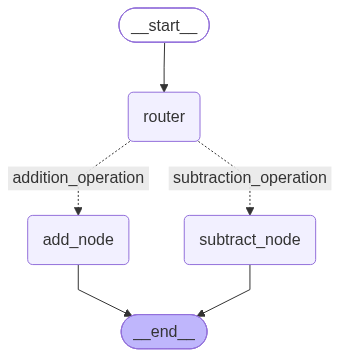

In [47]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [49]:
initial_state_1 = AgentState(number1 = 10, operation = "-", number2 = 5)

print(app.invoke(initial_state_1))

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}


{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}
